In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
simulation_df = pd.read_csv("../results/simulation_results.csv")
trajectory_df = pd.read_csv("../results/trajectory_results.csv")

In [26]:
simulation_df.head()

,run_id,N,T,initial_corruption_rate_parameter,beta,belief_threshold,initial_num_corrupted,initial_corruption_rate_actual,final_num_corrupted,final_num_honest,final_corruption_rate,spread_amount,spread_rate_change,full_corruption,no_spread
0,0,100,10,0.05,0.5,0.5,6,0.06,14,86,0.14,8,0.08,False,False
1,1,100,10,0.05,0.5,0.5,5,0.05,17,83,0.17,12,0.12,False,False
2,2,100,10,0.05,0.5,0.5,7,0.07,16,84,0.16,9,0.09,False,False
3,3,100,10,0.05,0.5,0.5,2,0.02,2,98,0.02,0,0.00,False,True
4,4,100,10,0.05,0.5,0.5,1,0.01,2,98,0.02,1,0.01,False,False


In [27]:
trajectory_df.head()

,run_id,time_step,N,T,initial_corruption_rate_parameter,beta,belief_threshold,num_corrupted,num_honest,corruption_rate,collaboration_rate
0,0,0,100,10,0.05,0.5,0.5,6,94,0.06,0.50
1,0,1,100,10,0.05,0.5,0.5,9,91,0.09,0.62
2,0,2,100,10,0.05,0.5,0.5,10,90,0.10,0.70
3,0,3,100,10,0.05,0.5,0.5,11,89,0.11,0.76
4,0,4,100,10,0.05,0.5,0.5,11,89,0.11,0.76


Final corruption rate distribution

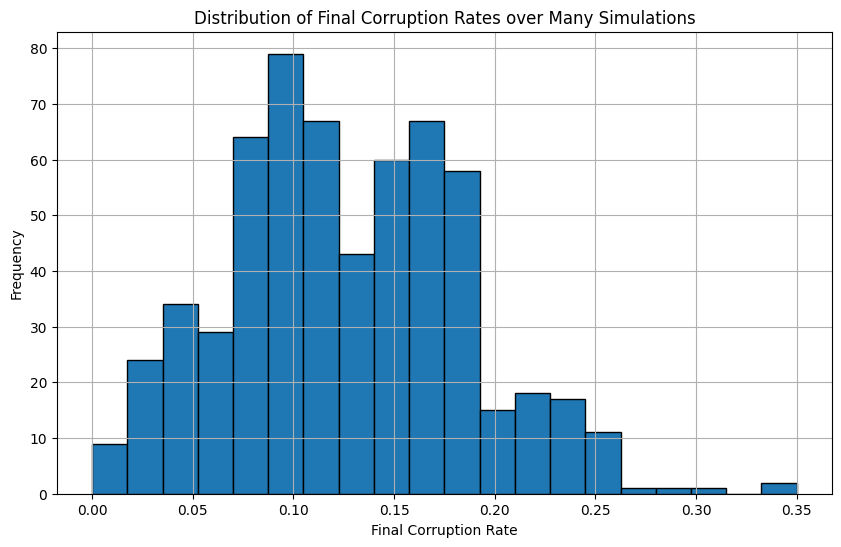

In [28]:
plt.figure(figsize=(10, 6))

plt.hist(
    simulation_df["final_corruption_rate"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Final Corruption Rate")
plt.ylabel("Frequency")
plt.title("Distribution of Final Corruption Rates over Many Simulations")
plt.grid(True)

plt.savefig("../figures/final_corruption_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Initial VS Final

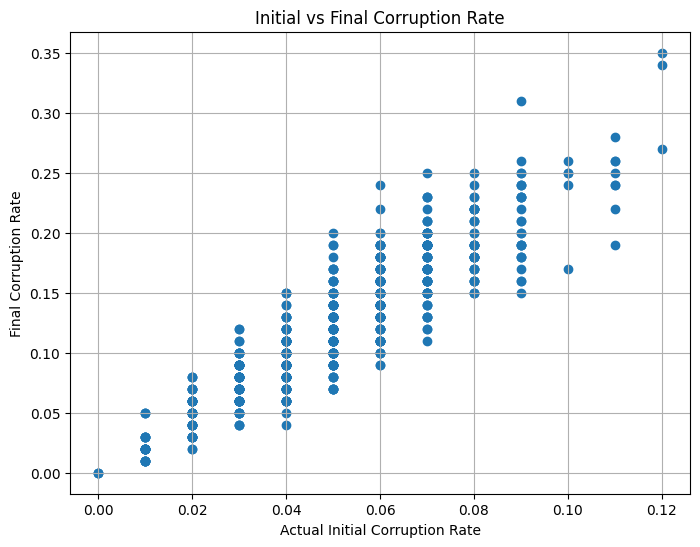

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    simulation_df["initial_corruption_rate_actual"],
    simulation_df["final_corruption_rate"]
)

plt.xlabel("Actual Initial Corruption Rate")
plt.ylabel("Final Corruption Rate")
plt.title("Initial vs Final Corruption Rate")
plt.grid(True)

plt.savefig("../figures/initial_vs_final_corruption.png", dpi=300, bbox_inches="tight")
plt.show()

Spread amount distribution

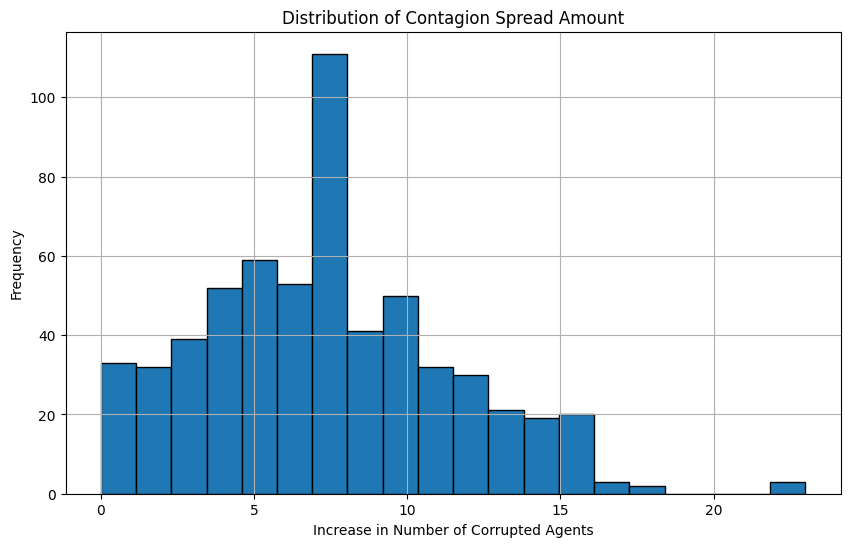

In [30]:
plt.figure(figsize=(10, 6))

plt.hist(
    simulation_df["spread_amount"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Increase in Number of Corrupted Agents")
plt.ylabel("Frequency")
plt.title("Distribution of Contagion Spread Amount")
plt.grid(True)

plt.savefig("../figures/spread_amount_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Corruption trajectories

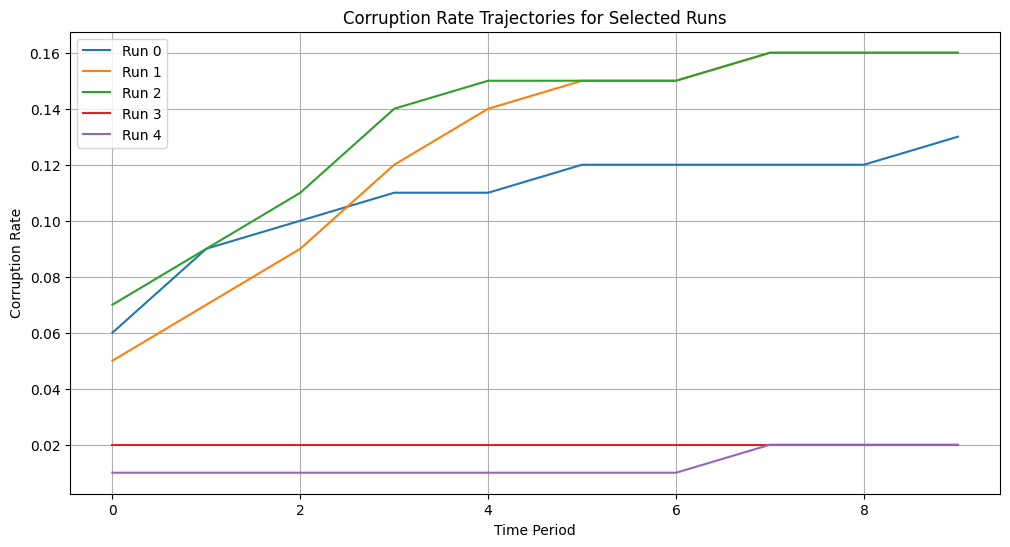

In [31]:
plt.figure(figsize=(12, 6))

for run_id in trajectory_df["run_id"].unique():
    run_data = trajectory_df[trajectory_df["run_id"] == run_id]

    plt.plot(
        run_data["time_step"],
        run_data["corruption_rate"],
        label=f"Run {run_id}"
    )

plt.xlabel("Time Period")
plt.ylabel("Corruption Rate")
plt.title("Corruption Rate Trajectories for Selected Runs")
plt.legend()
plt.grid(True)

plt.savefig("../figures/selected_corruption_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()

Collaboration trajectories

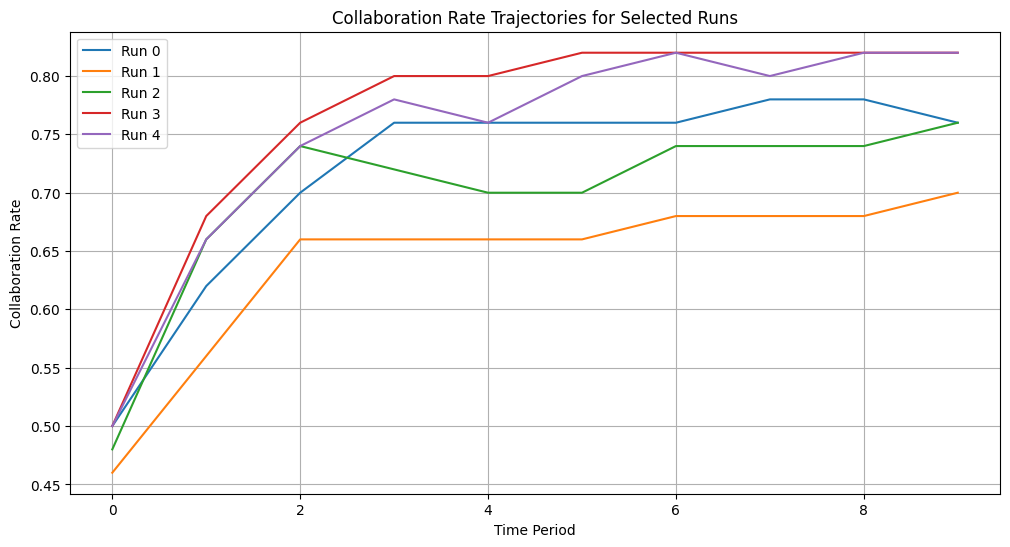

In [32]:
plt.figure(figsize=(12, 6))

for run_id in trajectory_df["run_id"].unique():
    run_data = trajectory_df[trajectory_df["run_id"] == run_id]

    plt.plot(
        run_data["time_step"],
        run_data["collaboration_rate"],
        label=f"Run {run_id}"
    )

plt.xlabel("Time Period")
plt.ylabel("Collaboration Rate")
plt.title("Collaboration Rate Trajectories for Selected Runs")
plt.legend()
plt.grid(True)

plt.savefig("../figures/selected_collaboration_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()

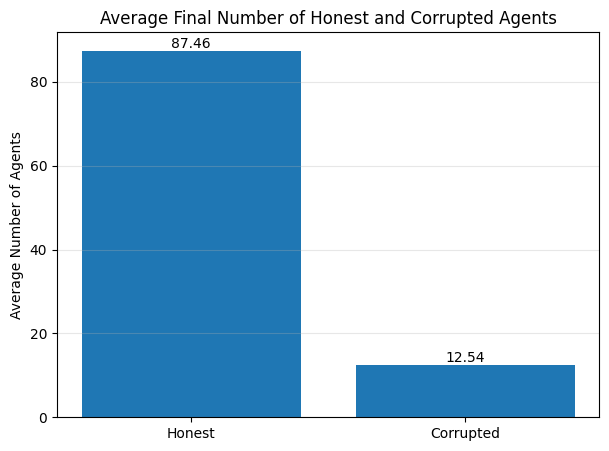

In [33]:
mean_final_honest = simulation_df["final_num_honest"].mean()
mean_final_corrupted = simulation_df["final_num_corrupted"].mean()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Honest", "Corrupted"],
    [mean_final_honest, mean_final_corrupted]
)

plt.ylabel("Average Number of Agents")
plt.title("Average Final Number of Honest and Corrupted Agents")
plt.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.savefig("../figures/average_final_honest_corrupted.png", dpi=300, bbox_inches="tight")
plt.show()